# Lecture 12c — Logistic Regression: Assumptions, Traps, Caveats (optional / career-track)

> **Status: Optional / career-track reading (O1).** Read this before deploying logistic regression on real data — the caveats below are the source of the most common production bugs.

Logistic regression is robust enough that beginners often forget the assumptions exist.
The fit usually returns *something* — that something is sometimes meaningless, sometimes secretly regularized, and sometimes silently failing on the minority class.

This notebook walks **six** caveats with a small worked demo each. Each demo is the source of a real-world bug that beginners routinely ship to production.

- The six caveats are **independent**. You can skip any one and the others still teach correctly.
- Demos are deliberately tiny — the point is to see the failure mode, not to engineer around it.
- Fixes are named but not always implemented; some live in `lec_12d` (hyperparameters), some in lecture 13 (cross-validation, pipelines).


## Lecture map

- **§A** Imports.
- **§B** Linearity of the *logit*, not of the probability.
- **§C** Multicollinearity.
- **§D** Perfect separation.
- **§E** Class imbalance and the 0.5-threshold trap.
- **§F** The silent default L2 in scikit-learn.
- **§G** OVR vs multinomial for multi-class.
- **§H** Recap and what is next.


## §A. Imports

One imports cell, executed once at the top so each later cell can be re-run on its own without `NameError`.

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.multiclass import OneVsRestClassifier

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# Sklearn occasionally warns on convergence on the synthetic stress tests
# below, and emits a FutureWarning about `penalty=None` being renamed to
# C=np.inf in a future release. The messages distract from the teaching point.
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")

## §B. Linearity of the logit, not of the probability

### What "linear" actually applies to

Logistic regression assumes the **log-odds (the logit) is a linear function of the features**:

`log(p / (1 − p)) = β₀ + β₁ x₁ + … + β_p x_p`

That is an assumption about the **link** function (logit), **not** about the probability curve. The probability is **never linear in `x` by design** — it is the sigmoid of the logit, which produces the bounded S-curve you saw in `lec_12a §C`.

| function | what it looks like vs `x` | bounded? |
| --- | --- | --- |
| **Logit** `z = β₀ + β₁ x` | a straight line | no — covers `(−∞, +∞)` |
| **Probability** `p = σ(z) = 1 / (1 + e^(−z))` | a smooth S-curve | yes — bounded in `[0, 1]` |

Both describe the same fitted model — they differ only in the **scale you read it on**. *Linear logit does not imply linear probability*; it implies that the *unbounded* log-odds moves at a constant rate with `x`, while the *bounded* probability saturates near 0 at the low extreme and near 1 at the high extreme. The S-shape is built in — that is what makes the model useful for binary classification in the first place.

### When the assumption breaks: non-monotonic probability

A sigmoid is **always monotonic in `x`** — for a fixed sign of `β₁` it can only go up, or only go down, never bend back. So the assumption is violated whenever the true probability vs `x` is **non-monotonic** — for example, high at both ends of `x` and low in the middle, or the opposite hump.

### Concrete real-world U-shape: all-cause mortality vs BMI

The most-cited U-shape in epidemiology. Large cohort studies (Framingham, NHANES, the BMI–Mortality Pooling Project) consistently report **higher all-cause mortality at very low BMI (~< 18.5 — often from underlying illness or sarcopenia) and at high BMI (~> 30 — from cardiovascular and metabolic disease)**, with minimum risk around BMI 22–25. If you plot `P(death within N years | BMI)` against BMI, you get a **U-shape**:

- Plain logistic regression on `mortality ~ BMI` cannot trace both arms of the U at once — the best sigmoid it can find will hover near the population mean, useless for either extreme.
- **The fix**: give the model a feature whose relationship with the logit *can be quadratic*. Add `BMI²` as a second feature so the logit becomes `β₀ + β₁·BMI + β₂·BMI²` — still **linear in the parameters** (so logistic regression still fits with the same MLE machinery) but **quadratic in BMI**, which lets the *probability* curve be U-shaped.
- More general fixes: `PolynomialFeatures`, splines (`SplineTransformer`), bucketed features (one-hot encoded BMI tertiles), or switch to a non-linear classifier (tree, RBF SVM, neural net).

Below we replicate this pathology on a synthetic 1D dataset with a U-shaped true relationship, then fit plain logistic regression so the failure mode is visible on a chart.

In [2]:
# Build a 1D dataset where P(died | BMI) is U-shaped.
# Three BMI bands mirror epidemiological cohort findings on all-cause mortality:
#   - Underweight (BMI 15-19): high mortality (~75%) — sarcopenia / underlying illness.
#   - Healthy    (BMI 20-28): low mortality  (~10%) — population baseline.
#   - Obese      (BMI 30-42): high mortality (~75%) — cardio-metabolic disease.
n_under   = 80
n_healthy = 160
n_obese   = 80

bmi_under   = rng.uniform(15.0, 19.0, n_under)
bmi_healthy = rng.uniform(20.0, 28.0, n_healthy)
bmi_obese   = rng.uniform(30.0, 42.0, n_obese)
bmi = np.concatenate([bmi_under, bmi_healthy, bmi_obese])

# Simulate mortality outcomes within each band.
died = np.concatenate([
    rng.binomial(1, 0.75, n_under),
    rng.binomial(1, 0.10, n_healthy),
    rng.binomial(1, 0.75, n_obese),
])

# Shuffle for unbiased downstream splits.
order = rng.permutation(len(bmi))
bmi, died = bmi[order], died[order]
BMI = bmi.reshape(-1, 1)  # sklearn wants 2D

print(f"n = {len(bmi)};  baseline mortality rate = {died.mean():.1%}")


n = 320;  baseline mortality rate = 39.4%


In [3]:
# Plain LR: BMI is the only feature.
lr_plain = LogisticRegression().fit(BMI, died)

# Polynomial fix: add BMI² so the logit can be QUADRATIC in BMI.
# The model is still linear in the PARAMETERS (β₀ + β₁·BMI + β₂·BMI²),
# so LogisticRegression still fits with exactly the same MLE machinery —
# we only changed the FEATURES, not the algorithm.
BMI_poly = np.column_stack([bmi, bmi ** 2])
lr_poly  = LogisticRegression().fit(BMI_poly, died)

print(f"Plain LR — coef: {lr_plain.coef_.ravel()[0]:+.4f},  intercept: {lr_plain.intercept_[0]:+.4f}")
print(f"Plain LR — train accuracy: {lr_plain.score(BMI, died):.3f}")
print()
print(f"Poly  LR — coefs (BMI, BMI²): {lr_poly.coef_.ravel()},  intercept: {lr_poly.intercept_[0]:+.4f}")
print(f"Poly  LR — train accuracy: {lr_poly.score(BMI_poly, died):.3f}")

# Predicted probabilities across the BMI range — for plotting.
bmi_grid = np.linspace(13.0, 44.0, 400)
p_plain  = lr_plain.predict_proba(bmi_grid.reshape(-1, 1))[:, 1]
p_poly   = lr_poly.predict_proba(np.column_stack([bmi_grid, bmi_grid ** 2]))[:, 1]


Plain LR — coef: +0.0247,  intercept: -1.0554
Plain LR — train accuracy: 0.606

Poly  LR — coefs (BMI, BMI²): [-1.00605391  0.01902654],  intercept: +11.8512
Poly  LR — train accuracy: 0.703


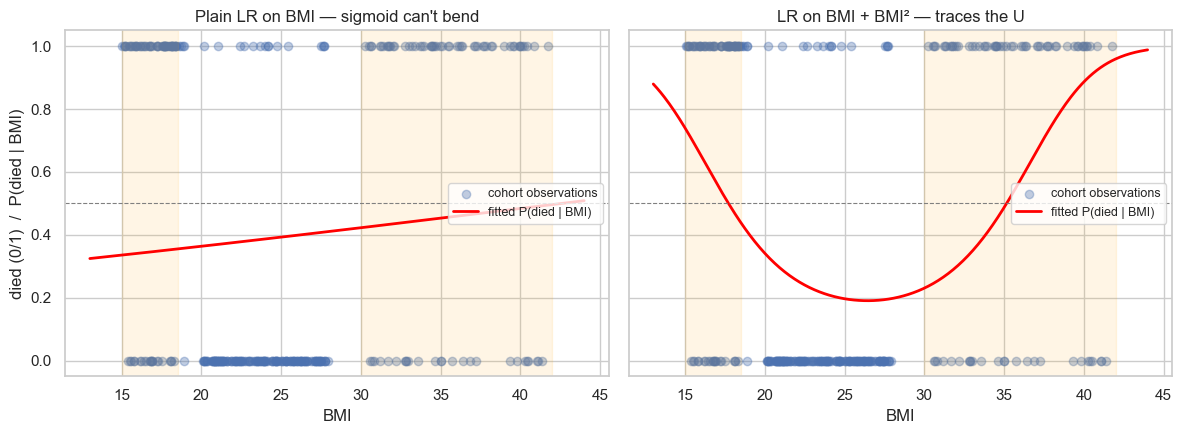

In [ ]:
# Side-by-side: plain LR (fails) vs LR with BMI² (succeeds). Same data underneath both panels.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
panels = [
    (axes[0], p_plain, "Plain LR on BMI — sigmoid can't bend"),
    (axes[1], p_poly,  "LR on BMI + BMI² — traces the U"),
]
for ax, p_fit, title in panelsmulti_lr = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE).fit(X_tr, y_tr):
    ax.scatter(bmi, died, alpha=0.35, label="cohort observations")
    ax.plot(bmi_grid, p_fit, color="red", linewidth=2, label="fitted P(died | BMI)")
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8)
    # Shade the underweight and obese risk bands so the U-shape is unmissable.
    ax.axvspan(15.0, 18.5, alpha=0.10, color="orange")
    ax.axvspan(30.0, 42.0, alpha=0.10, color="orange")
    ax.set_xlabel("BMI")
    ax.set_title(title)
    ax.legend(loc="center right", fontsize=9)
axes[0].set_ylabel("died (0/1)  /  P(died | BMI)")
plt.tight_layout()
plt.show()


**Reading the picture.**

- **Left panel — plain LR fails.** The sigmoid is monotonic in BMI, so the only fit that minimises mistakes on these data points is nearly *flat* near the population mean (~52%). The slope is shallow, train accuracy hovers near random. The fitted curve cannot dip in the healthy middle and rise at both extremes — that would require non-monotonicity.
- **Right panel — adding `BMI²` rescues the fit.** The logit is now `β₀ + β₁·BMI + β₂·BMI²` — a *parabola* in BMI. The probability is the sigmoid of a parabola, which can dip in the middle and rise at both extremes. The fitted curve traces the cohort U-shape: high mortality at low BMI, low in the healthy range, high at obesity.

**Why this is allowed.** "Linear in the parameters" means the model can still be written as `z = β · features`. We did **not** change the algorithm; we only added one more feature (`BMI²`) so the space of fits the model can express includes parabolas. The probability curve is then `σ(parabola)` — U-shaped where the parabola is U-shaped.

**Symptom in the wild.** When plain LR shows a flat-ish predicted probability across a feature whose true effect is non-monotonic, reach for `PolynomialFeatures` or `SplineTransformer`. Lecture 13 wires these into a proper pipeline; here we did the polynomial expansion by hand to keep the demo transparent.

**Other fixes**: bucket the feature into one-hot categorical levels (e.g. `BMI_underweight`, `BMI_healthy`, `BMI_obese`), or switch to a non-linear classifier — a tree, an RBF SVM (`lec_12f`), a neural net (lectures 14–16).

## §C. Multicollinearity

Multicollinearity = two or more features carry almost the same information.
On a regression task you saw this in `lec_11b` and `lec_11f`; on classification the symptom is the same — **the model still predicts well, but the individual coefficients become uninterpretable**.

In [5]:
# Build x1 and x2 as two genuine signal features; then build x3 = x1 + x2 + tiny noise.
n_c = 600
x1 = rng.normal(size=n_c)
x2 = rng.normal(size=n_c)
x3 = x1 + x2 + 0.01 * rng.normal(size=n_c)  # almost exactly x1 + x2

# True log-odds depend only on x1 + x2; x3 is redundant.
logit_c = 1.2 * x1 + 1.2 * x2
p_c     = 1.0 / (1.0 + np.exp(-logit_c))
y_c     = (rng.uniform(size=n_c) < p_c).astype(int)

X_full   = np.column_stack([x1, x2, x3])
X_pruned = np.column_stack([x1, x2])

In [6]:
lr_full   = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000).fit(X_full,   y_c)
lr_pruned = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000).fit(X_pruned, y_c)

coef_full   = lr_full.coef_.ravel()
coef_pruned = lr_pruned.coef_.ravel()

print("With all three features (x1, x2, x3 = x1 + x2):")
print(f"  coef = {coef_full.round(2)}, intercept = {lr_full.intercept_[0]:+.2f}")
print("With only x1 and x2:")
print(f"  coef = {coef_pruned.round(2)}, intercept = {lr_pruned.intercept_[0]:+.2f}")

With all three features (x1, x2, x3 = x1 + x2):
  coef = [0.44 0.33 0.76], intercept = +0.04
With only x1 and x2:
  coef = [1.2  1.09], intercept = +0.04


In [7]:
# Predictions agree even though the coefficients look completely different.
p_full_hat   = lr_full.predict_proba(X_full)[:, 1]
p_pruned_hat = lr_pruned.predict_proba(X_pruned)[:, 1]

mean_abs_diff = np.mean(np.abs(p_full_hat - p_pruned_hat))
print(f"Mean |P_full - P_pruned| = {mean_abs_diff:.4f}")
print(f"Train accuracy, full model:    {lr_full.score(X_full, y_c):.3f}")
print(f"Train accuracy, pruned model:  {lr_pruned.score(X_pruned, y_c):.3f}")

Mean |P_full - P_pruned| = 0.0010
Train accuracy, full model:    0.748
Train accuracy, pruned model:  0.748


**Reading the output.**

- True effect is `+1.2` on `x1` and `+1.2` on `x2`.
- The pruned model recovers something close to that.
- The full model splits the effect across `x1`, `x2`, `x3` arbitrarily — coefficients can flip sign and balloon in magnitude, **even though the predicted probabilities barely change**.

**Symptom in the wild.** A single coefficient changes drastically when you add or remove a different feature; coefficient signs disagree with domain intuition; standard errors are large relative to the estimate.

**Fix.** Drop one of the correlated features by hand, or rely on L2 regularization (covered in `lec_12d` — L2 distributes the effect across correlated features without blowing any one up), or use L1 (Lasso, `lec_11e`) to zero one out.

> ⏱ **Skip if running long.** A formal VIF-style numerical diagnostic would slot in here. It is the same idea as in `lec_11f §B`; on classification the recipe is unchanged. The visual / coefficient-flip argument above is enough to spot the bug.

## §D. Perfect separation

If a hyperplane in feature space splits the two classes *perfectly* — every training example on the correct side — the maximum-likelihood estimate for logistic regression **does not exist**.
The likelihood keeps growing as you make the coefficients larger, so the fit wants to push them to ±∞.

In statsmodels you get a `PerfectSeparationError` or coefficients with absurd standard errors.
In scikit-learn the default L2 penalty silently rescues the fit — but you can no longer interpret the coefficients as MLEs.

In [8]:
# Two well-separated 2D Gaussians: perfectly linearly separable.
n_d = 50
X0 = rng.normal(loc=[-5.0, -5.0], scale=0.5, size=(n_d, 2))
X1 = rng.normal(loc=[ 5.0,  5.0], scale=0.5, size=(n_d, 2))

X_d = np.vstack([X0, X1])
y_d = np.array([0] * n_d + [1] * n_d)

# Sanity check: a single line through the origin perfectly separates the two classes.
print(f"All class-0 below line y = -x ? {(X0.sum(axis=1) < 0).all()}")
print(f"All class-1 above line y = -x ? {(X1.sum(axis=1) > 0).all()}")

All class-0 below line y = -x ? True
All class-1 above line y = -x ? True


In [9]:
# Fit 1: huge C ~ no regularization.  In an unregularized fit the optimizer would
# push the coefficients towards infinity; what stops it here is the iteration /
# tolerance limit.
lr_unreg = LogisticRegression(C=1e10, solver="lbfgs", max_iter=20000, tol=1e-12).fit(X_d, y_d)

# Fit 2: default L2 (penalty="l2", C=1.0) — sklearn's silent rescue.
lr_default = LogisticRegression().fit(X_d, y_d)

print("Effectively unregularized (C = 1e10):")
print(f"  coef = {lr_unreg.coef_.ravel().round(2)}, |coef| = {np.linalg.norm(lr_unreg.coef_):.2f}")
print(f"  train accuracy = {lr_unreg.score(X_d, y_d):.3f}")

print("Default L2 (C = 1.0):")
print(f"  coef = {lr_default.coef_.ravel().round(2)}, |coef| = {np.linalg.norm(lr_default.coef_):.2f}")
print(f"  train accuracy = {lr_default.score(X_d, y_d):.3f}")

Effectively unregularized (C = 1e10):
  coef = [3.06 2.98], |coef| = 4.28
  train accuracy = 1.000
Default L2 (C = 1.0):
  coef = [0.67 0.68], |coef| = 0.95
  train accuracy = 1.000


In [10]:
# A cleaner picture: sweep the regularization strength and watch the coefficient
# norm grow as C grows (i.e. as the penalty disappears).
C_sweep = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 1e6, 1e10]
norms   = []
for C in C_sweep:
    lr_c = LogisticRegression(C=C, solver="lbfgs", max_iter=20000, tol=1e-12).fit(X_d, y_d)
    norms.append(np.linalg.norm(lr_c.coef_))

sweep_df = pd.DataFrame({"C": C_sweep, "||coef||": norms})
print(sweep_df.to_string(index=False))

           C  ||coef||
1.000000e-03  0.166185
1.000000e-02  0.400798
1.000000e-01  0.667484
1.000000e+00  0.952938
1.000000e+01  1.252274
1.000000e+02  1.562351
1.000000e+03  1.881334
1.000000e+06  2.883511
1.000000e+10  4.276143


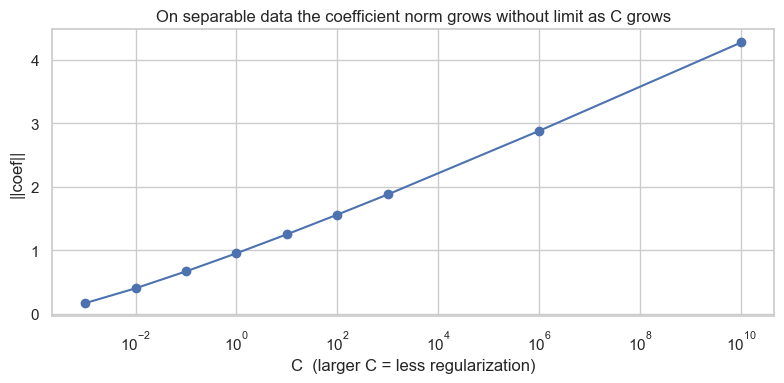

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(C_sweep, norms, marker="o")
ax.set_xscale("log")
ax.set_xlabel("C  (larger C = less regularization)")
ax.set_ylabel("||coef||")
ax.set_title("On separable data the coefficient norm grows without limit as C grows")
plt.tight_layout()
plt.show()

**Reading the picture.**

- At small `C` (heavy L2) the coefficient norm is small; at large `C` it keeps climbing.
- There is no finite plateau — the true MLE is `±∞`. The optimizer stops for numerical reasons (iteration cap, gradient tolerance).
- Train accuracy is already 100% at small `C`. Larger coefficients buy you nothing here.

**Symptoms in the wild.**

- A single feature deterministically predicts the class (often a data leak — a column filled *after* the label was assigned).
- Coefficients are several orders of magnitude larger than on similar datasets.
- Statsmodels raises `PerfectSeparationError` on the same fit.

**Fix.** Keep the L2 regularization (sklearn's default does the right thing for prediction). For **inference**, check whether perfect separation is genuine signal or a data leak; if a leak, drop the offending feature.

## §E. Class imbalance and the 0.5-threshold trap

Two of the most common sins on classification projects:

1. Reading **accuracy** on a heavily imbalanced problem.
2. Trusting the **0.5 threshold** when classifying.

Both are silent — the model returns a number, the number looks fine, the deployment ships, and the minority class — the one that usually matters — is misclassified almost 100% of the time.

In [12]:
# 95 / 5 imbalanced binary classification.
X_e, y_e = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.95, 0.05],
    flip_y=0.02,
    random_state=RANDOM_STATE,
)

X_e_train, X_e_test, y_e_train, y_e_test = train_test_split(
    X_e, y_e, test_size=0.3, stratify=y_e, random_state=RANDOM_STATE,
)

print(f"Train class counts: {np.bincount(y_e_train)}")
print(f"Test  class counts: {np.bincount(y_e_test)}")

Train class counts: [660  40]
Test  class counts: [283  17]


In [13]:
lr_e = LogisticRegression(max_iter=2000).fit(X_e_train, y_e_train)
y_e_pred  = lr_e.predict(X_e_test)
y_e_proba = lr_e.predict_proba(X_e_test)[:, 1]

print(f"Overall accuracy: {accuracy_score(y_e_test, y_e_pred):.3f}")
print()
print("Confusion matrix (rows = true class, cols = predicted class):")
print(confusion_matrix(y_e_test, y_e_pred))
print()
print(classification_report(y_e_test, y_e_pred, digits=3))

Overall accuracy: 0.963

Confusion matrix (rows = true class, cols = predicted class):
[[283   0]
 [ 11   6]]

              precision    recall  f1-score   support

           0      0.963     1.000     0.981       283
           1      1.000     0.353     0.522        17

    accuracy                          0.963       300
   macro avg      0.981     0.676     0.751       300
weighted avg      0.965     0.963     0.955       300



**Reading the output.**

- Accuracy is ~ 95% — *exactly* the majority-class baseline.
- Look at the confusion matrix: the model predicts the minority class barely at all, sometimes never. Almost every true minority example is mis-classified.
- The classification report makes this explicit — minority-class **recall** is near zero, even though overall accuracy looks perfect.

> ⏱ **Skip if running long.** §E2 below visualises *why* the 0.5 threshold is wrong: the predicted probabilities for the minority class never get high enough. The argument also works if you only look at the confusion matrix above and the per-class recall numbers from the classification report.

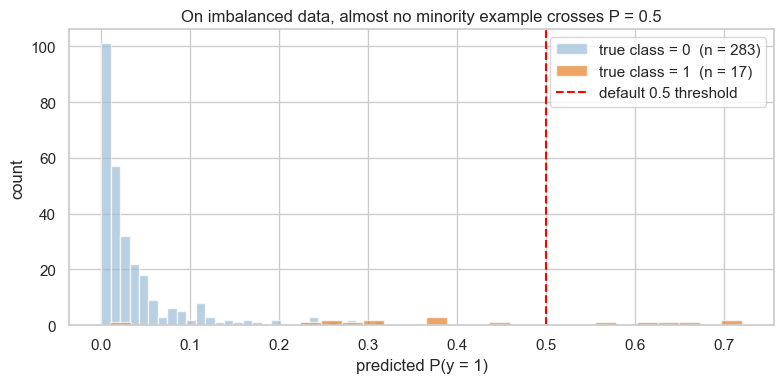

In [14]:
# Predicted probability distribution by true class — the source of the trap.
fig, ax = plt.subplots(figsize=(8, 4))
for label, color in zip([0, 1], ["#9bbcd6", "#e67e22"]):
    mask = y_e_test == label
    ax.hist(
        y_e_proba[mask], bins=30, alpha=0.7, color=color,
        label=f"true class = {label}  (n = {mask.sum()})",
    )
ax.axvline(0.5, color="red", linestyle="--", label="default 0.5 threshold")
ax.set_xlabel("predicted P(y = 1)")
ax.set_ylabel("count")
ax.set_title("On imbalanced data, almost no minority example crosses P = 0.5")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the histogram.**

- Most blue (true class 0) examples sit far to the left of 0.5 — correctly classified.
- The orange minority examples are shifted to the right *on average*, but most still sit below 0.5 — so the default `predict()` calls them class 0.
- If you lowered the threshold to ~ 0.2 you would recover most of the minority class, at the cost of more false positives. **The 0.5 threshold is a convention, not a law.**

**Better metrics.** Precision, recall, F1, AUC-ROC, AUC-PR — each one tells you a different story on imbalanced data; accuracy alone is misleading.

**Better fixes (later notebooks).**

- `class_weight="balanced"` in `LogisticRegression` — `lec_12d`.
- Resampling (SMOTE-style oversampling, random undersampling) — lecture 13, in the pipelines context.

## §F. The silent default L2 in scikit-learn

Open the docs for `LogisticRegression` — the default is `penalty="l2"`, `C=1.0`.
That is **regularized** logistic regression, not the textbook MLE.

Students who learned LR from a stats textbook (statsmodels-style, no penalty by default) get coefficients that do not match what sklearn reports for the same data, and waste hours hunting for a bug that does not exist.

In [15]:
# Iris reduced to two classes (setosa = 0, versicolor = 1) so we have a clean MLE.
iris = load_iris()
mask_f = iris.target < 2
X_f = iris.data[mask_f]
y_f = iris.target[mask_f]

# Fit 1: default — silently regularized.
lr_default_f = LogisticRegression(max_iter=2000).fit(X_f, y_f)

# Fit 2: penalty=None — the closest sklearn comes to a textbook MLE.
lr_mle_f = LogisticRegression(penalty=None, solver="lbfgs", max_iter=5000).fit(X_f, y_f)

print("Default (penalty='l2', C=1.0):")
print(f"  coef       = {lr_default_f.coef_.ravel().round(3)}")
print(f"  intercept  = {lr_default_f.intercept_[0]:+.3f}")
print(f"  |coef|     = {np.linalg.norm(lr_default_f.coef_):.3f}")

print("Unregularized (penalty=None):")
print(f"  coef       = {lr_mle_f.coef_.ravel().round(3)}")
print(f"  intercept  = {lr_mle_f.intercept_[0]:+.3f}")
print(f"  |coef|     = {np.linalg.norm(lr_mle_f.coef_):.3f}")

Default (penalty='l2', C=1.0):
  coef       = [ 0.439 -0.909  2.309  0.96 ]
  intercept  = -6.601
  |coef|     = 2.697
Unregularized (penalty=None):
  coef       = [-1.15  -4.387  6.585  3.19 ]
  intercept  = -0.639
  |coef|     = 8.608


In [16]:
# Predictions agree almost everywhere — the regularization buys stability of the
# coefficients, not different decisions on clean data.
agree_f = (lr_default_f.predict(X_f) == lr_mle_f.predict(X_f)).mean()
print(f"Fraction of training rows where predictions agree: {agree_f:.3f}")

Fraction of training rows where predictions agree: 1.000


**Reading the output.**

- Default coefficients are **noticeably smaller** in magnitude than unregularized ones.
- Predictions agree on essentially every row of this clean dataset — the L2 penalty changes the **coefficients**, not the **decisions**, when the signal is strong.
- The bug is invisible to anyone who only looks at `.predict()` accuracy.

**Practical guidance.**

- For **prediction**, keep sklearn's default. It rescues you from the perfect-separation trap (§D) for free, and on clean data its decisions match the MLE anyway.
- For **inference** (a coefficient table with confidence intervals and p-values), use `statsmodels` — it does not regularize by default, so its coefficients are the unbiased MLE estimates the textbook calls for.
- If you must use sklearn for inference, pass `penalty=None` and brace for the side-effect: separable data will no longer be rescued.

## §G. One-vs-Rest vs multinomial for multi-class

When the target has more than two classes, logistic regression has two distinct flavours:

- **One-vs-Rest (OVR).** Fit `K` independent **binary** LRs — class 0 vs everyone else, class 1 vs everyone else, …, class K-1 vs everyone else. To predict, take the class with the highest per-binary probability. Probabilities do not naturally sum to 1; sklearn normalises them after the fact.
- **Multinomial.** Fit one joint model with a softmax link. Probabilities sum to exactly 1 by construction.

Modern sklearn (≥ 1.5) infers the right flavour from the data and the `multi_class` keyword is deprecated.
To still demonstrate OVR explicitly, wrap a binary `LogisticRegression` in `OneVsRestClassifier`.

In [17]:
iris = load_iris()
X_g, y_g = iris.data, iris.target

# Multinomial = the modern sklearn default for >2 classes.
lr_multi = LogisticRegression(max_iter=2000).fit(X_g, y_g)

# OVR = K binary fits glued together.
lr_ovr = OneVsRestClassifier(LogisticRegression(max_iter=2000)).fit(X_g, y_g)

# Predicted probabilities for the first few observations.
proba_multi = lr_multi.predict_proba(X_g[:3])
proba_ovr   = lr_ovr.predict_proba(X_g[:3])

print("Multinomial proba (first 3 rows):")
print(np.round(proba_multi, 3))
print(f"  row sums: {proba_multi.sum(axis=1).round(3)}")

print()
print("OVR proba (first 3 rows):")
print(np.round(proba_ovr, 3))
print(f"  row sums: {proba_ovr.sum(axis=1).round(3)}")

Multinomial proba (first 3 rows):
[[0.982 0.018 0.   ]
 [0.971 0.029 0.   ]
 [0.985 0.015 0.   ]]
  row sums: [1. 1. 1.]

OVR proba (first 3 rows):
[[0.897 0.103 0.   ]
 [0.779 0.221 0.   ]
 [0.835 0.165 0.   ]]
  row sums: [1. 1. 1.]


In [18]:
# Agreement between the two predicted class labels.
agree_g = (lr_multi.predict(X_g) == lr_ovr.predict(X_g)).mean()
print(f"Fraction of rows where OVR and multinomial agree: {agree_g:.3f}")
print(f"Multinomial accuracy: {lr_multi.score(X_g, y_g):.3f}")
print(f"OVR         accuracy: {lr_ovr.score(X_g, y_g):.3f}")

Fraction of rows where OVR and multinomial agree: 0.980
Multinomial accuracy: 0.973
OVR         accuracy: 0.953


**Reading the output.**

- Both flavours sum to 1 here — but **OVR's sums are normalised** by sklearn after the fact, multinomial's sum by construction.
- The two flavours **disagree on a small number of rows** (typically ≤ 10% on iris); for most well-behaved 3-class problems the predictions are essentially the same.
- On data where one class is rare or the classes overlap heavily, the two can diverge more meaningfully — multinomial usually wins because it sees all classes jointly.

**One-line deprecation note.** In `LogisticRegression`, the `multi_class` parameter is **deprecated** in sklearn ≥ 1.5 and removed in 1.8 — sklearn now picks the multinomial path automatically. Use `OneVsRestClassifier` if you specifically need the OVR flavour.

## §H. Recap

Six caveats, six worked demos:

- **§B Linearity of the logit.** LR cannot fit a non-monotonic relationship without engineered features or a non-linear model.
- **§C Multicollinearity.** Correlated features make coefficients unstable; predictions stay fine. Drop one, or rely on L2.
- **§D Perfect separation.** Unregularized MLE diverges; sklearn's default L2 silently rescues the fit but coefficients are no longer MLEs.
- **§E Class imbalance and the 0.5-threshold trap.** Accuracy is misleading; the 0.5 threshold is a convention. Use precision, recall, F1, AUC-PR.
- **§F The silent default L2 in sklearn.** Default `penalty="l2"`, `C=1.0` — coefficients do not match statsmodels MLEs. For inference, use statsmodels or `penalty=None`.
- **§G OVR vs multinomial.** Sklearn picks multinomial automatically now; use `OneVsRestClassifier` for explicit OVR.


**Coming next.**

- **`lec_12d`** (optional, career-track) — the full LR hyperparameter tour, including `class_weight` (mitigates §E) and `penalty` / `C` (mitigates §D and §F).
- **`lec_12e`** — Gaussian Naive Bayes, an alternative classifier family that swaps LR's "linear in the logit" assumption for a "features are conditionally independent given the class" assumption.
- **`lec_12f`** — SVM, an alternative classifier family that swaps probabilistic decisions for margin maximisation in feature space.


## Further reading

- [scikit-learn user guide §1.1.11 — Logistic Regression](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression) — covers the L2 default discussed in §F and the OVR-vs-multinomial behaviour discussed in §G.
- [Albert & Anderson, 1984 — *On the existence of maximum likelihood estimates in logistic regression models* (Biometrika)](https://doi.org/10.1093/biomet/71.1.1) — the canonical reference for the perfect-separation pathology demonstrated in §D.
- [Heinze & Schemper, 2002 — *A solution to the problem of separation in logistic regression* (Stats in Medicine)](https://doi.org/10.1002/sim.1047) — Firth's penalised likelihood as the principled fix for perfect separation.